# Regresión Logística — Tasa de Violencia Intrafamiliar con Analfabetismo en Pareja

## Problema
Predecir si un departamento-año tiene **alto riesgo** de violencia intrafamiliar en pareja donde al menos uno es analfabeto, en relación al total de matrimonios registrados ese año.

## Variable respuesta
$$\text{tasa}_{d,a} = \frac{\text{casos violencia analfabeta en pareja}_{d,a}}{\text{total matrimonios}_{d,a}}$$

Se binariza: **1 = alto riesgo** (tasa ≥ mediana), **0 = bajo riesgo** (tasa < mediana)

## Filtros aplicados al dataset de violencia (Opción A)
- `VIC_REL_AGR` ∈ {1, 2} → agresor es esposo/a o conviviente
- `VIC_ALFAB == 2` OR `AGR_ALFAB == 2` → al menos uno es analfabeto

## Nivel de análisis
**Departamento × Año** — 22 departamentos × ~12 años = ~264 observaciones

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn pyreadstat -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
import pyreadstat

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, accuracy_score,
    f1_score, roc_auc_score, roc_curve
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

SEMILLA = 42

DEPARTAMENTOS_MAP = {
    1: 'Guatemala', 2: 'El Progreso', 3: 'Sacatepéquez', 4: 'Chimaltenango',
    5: 'Escuintla', 6: 'Santa Rosa', 7: 'Sololá', 8: 'Totonicapán',
    9: 'Quetzaltenango', 10: 'Suchitepéquez', 11: 'Retalhuleu', 12: 'San Marcos',
    13: 'Huehuetenango', 14: 'Quiché', 15: 'Baja Verapaz', 16: 'Alta Verapaz',
    17: 'Petén', 18: 'Izabal', 19: 'Zacapa', 20: 'Chiquimula',
    21: 'Jalapa', 22: 'Jutiapa'
}

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## Paso 1 — Carga y agregación de matrimonios

Se carga cada archivo `.sav` de matrimonios (2009–2021), se agrega por **AÑOREG × DEPREG** y se calculan:
- `total_matrimonios` — denominador de la tasa
- `pct_alfab_hom` — % de hombres analfabetos en matrimonios (ESCHOM == 1)
- `pct_alfab_muj` — % de mujeres analfabetas en matrimonios (ESCMUJ == 1)
- `pct_pareja_analfabeta` — % de parejas donde al menos uno es analfabeto

In [3]:
def cargar_matrimonios(ruta='data/matrimonios/sav'):
    archivos = sorted(Path(ruta).glob('*.sav'))
    listas = []
    for archivo in archivos:
        df_t, _ = pyreadstat.read_sav(str(archivo))
        # Normalizar nombres de columna a mayúsculas
        df_t.columns = [c.upper() for c in df_t.columns]
        listas.append(df_t)
    df = pd.concat(listas, ignore_index=True)
    return df


df_mat = cargar_matrimonios()
print(f'Registros matrimonios: {len(df_mat):,}')
print(f'Columnas disponibles: {list(df_mat.columns)}')

Registros matrimonios: 887,492
Columnas disponibles: ['DEPREG', 'MUPREG', 'MESREG', 'AÑOREG', 'CLAUNI', 'EDADHOM', 'EDADMUJ', 'GETHOM', 'GETMUJ', 'NACHOM', 'NACMUJ', 'OCUHOM', 'OCUMUJ', 'NUPHON', 'NUPMUJ', 'DEPOCU', 'MUPOCU', 'MESOCU', 'AÑOOCU', 'AREAG', 'ESCHOM', 'ESCMUJ', 'DIAOCU', 'PUEHOM', 'PUEMUJ', 'CIUOHOM', 'CIUOMUJ', 'AREAGOCU', 'NUNUHO', 'NUNUMU']


In [4]:
# Verificar valores únicos de columnas clave
print('AÑOREG únicos:', sorted(df_mat['AÑOREG'].dropna().unique().tolist()))
print('DEPREG únicos:', sorted(df_mat['DEPREG'].dropna().astype(int).unique().tolist()))
print('ESCHOM únicos:', sorted(df_mat['ESCHOM'].dropna().unique().tolist()))
print('ESCMUJ únicos:', sorted(df_mat['ESCMUJ'].dropna().unique().tolist()))

AÑOREG únicos: [9.0, 10.0, 2010.0, 2011.0, 2012.0, 2013.0, 2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0]
DEPREG únicos: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
ESCHOM únicos: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 9.0]
ESCMUJ únicos: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 9.0]


In [5]:
# ESCHOM/ESCMUJ: 1 = Ninguno/Analfabeto  (estándar INE Guatemala)
CODIGO_ANALFABETO_MAT = 1

def agregar_matrimonios(df):
    df = df.copy()
    df['ANIO'] = pd.to_numeric(df['AÑOREG'], errors='coerce').dropna()
    df['DEPTO_COD'] = pd.to_numeric(df['DEPREG'], errors='coerce')
    df['ESCHOM_N'] = pd.to_numeric(df['ESCHOM'], errors='coerce')
    df['ESCMUJ_N'] = pd.to_numeric(df['ESCMUJ'], errors='coerce')

    # Indicadores de analfabetismo por individuo
    df['hom_analfabeto'] = (df['ESCHOM_N'] == CODIGO_ANALFABETO_MAT).astype(int)
    df['muj_analfabeta'] = (df['ESCMUJ_N'] == CODIGO_ANALFABETO_MAT).astype(int)
    df['pareja_analfabeta'] = ((df['hom_analfabeto'] == 1) | (df['muj_analfabeta'] == 1)).astype(int)

    validos = df.dropna(subset=['ANIO', 'DEPTO_COD'])
    validos['ANIO'] = validos['ANIO'].astype(int)
    validos['DEPTO_COD'] = validos['DEPTO_COD'].astype(int)

    agg = validos.groupby(['ANIO', 'DEPTO_COD']).agg(
        total_matrimonios=('DEPTO_COD', 'count'),
        n_hom_analfabeto=('hom_analfabeto', 'sum'),
        n_muj_analfabeta=('muj_analfabeta', 'sum'),
        n_pareja_analfabeta=('pareja_analfabeta', 'sum')
    ).reset_index()

    agg['pct_alfab_hom'] = agg['n_hom_analfabeto'] / agg['total_matrimonios'] * 100
    agg['pct_alfab_muj'] = agg['n_muj_analfabeta'] / agg['total_matrimonios'] * 100
    agg['pct_pareja_analfabeta'] = agg['n_pareja_analfabeta'] / agg['total_matrimonios'] * 100
    agg['Departamento'] = agg['DEPTO_COD'].map(DEPARTAMENTOS_MAP)

    return agg


df_mat_agg = agregar_matrimonios(df_mat)
print(f'Filas agregadas (año × depto): {len(df_mat_agg):,}')
print(f'Años cubiertos: {df_mat_agg["ANIO"].min()} – {df_mat_agg["ANIO"].max()}')
display(df_mat_agg.head(10))

Filas agregadas (año × depto): 308
Años cubiertos: 9 – 2021


,ANIO,DEPTO_COD,total_matrimonios,n_hom_analfabeto,n_muj_analfabeta,n_pareja_analfabeta,pct_alfab_hom,pct_alfab_muj,pct_pareja_analfabeta,Departamento
0,9,1,8638,0,0,0,0.0,0.0,0.0,Guatemala
1,9,2,668,0,0,0,0.0,0.0,0.0,El Progreso
2,9,3,1677,0,0,0,0.0,0.0,0.0,Sacatepéquez
3,9,4,2563,0,0,0,0.0,0.0,0.0,Chimaltenango
4,9,5,2219,0,0,0,0.0,0.0,0.0,Escuintla
5,9,6,1482,0,0,0,0.0,0.0,0.0,Santa Rosa
6,9,7,1680,0,0,0,0.0,0.0,0.0,Sololá
7,9,8,2061,0,0,0,0.0,0.0,0.0,Totonicapán
8,9,9,2137,0,0,0,0.0,0.0,0.0,Quetzaltenango
9,9,10,2532,0,0,0,0.0,0.0,0.0,Suchitepéquez


---
## Paso 2 — Carga y filtrado de violencia intrafamiliar

Se aplican los **tres filtros (Opción A)**:
1. `VIC_REL_AGR` ∈ {1, 2} → el agresor es esposo/a o conviviente (relación de pareja)
2. `VIC_ALFAB == 2` OR `AGR_ALFAB == 2` → al menos uno de los dos es analfabeto

Luego se agrega por **HEC_ANO × Departamento** para obtener el numerador de la tasa.

In [6]:
def cargar_violencia(ruta='data/violencia-intrafamiliar'):
    archivos = sorted(Path(ruta).glob('*.sav'))
    listas = []
    for archivo in archivos:
        df_t, _ = pyreadstat.read_sav(str(archivo))
        anio = int(archivo.stem.split('-')[0])
        df_t['ANIO'] = anio
        listas.append(df_t)
    df = pd.concat(listas, ignore_index=True)
    codigo_depto = df['DEPTO_MCPIO'].dropna().astype(int).floordiv(100)
    df['DEPTO_COD'] = codigo_depto.reindex(df.index)
    df['Departamento'] = df['DEPTO_COD'].map(DEPARTAMENTOS_MAP)
    return df


df_vio = cargar_violencia()
print(f'Registros violencia cargados: {len(df_vio):,}')
print(f'Columnas clave disponibles:')
for col in ['VIC_REL_AGR', 'VIC_ALFAB', 'AGR_ALFAB', 'VIC_EST_CIV', 'ANIO']:
    if col in df_vio.columns:
        print(f'  {col}: {sorted(df_vio[col].dropna().unique().tolist())}')

Registros violencia cargados: 387,257
Columnas clave disponibles:
  VIC_REL_AGR: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]
  VIC_ALFAB: [1.0, 2.0, 9.0]
  AGR_ALFAB: [1.0, 2.0, 9.0]
  VIC_EST_CIV: [1.0, 2.0, 3.0, 4.0, 5.0, 9.0]
  ANIO: [2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]


In [7]:
# Valores según diccionario INE
# VIC_REL_AGR: 1 = Esposo/a, 2 = Conviviente
# VIC_ALFAB / AGR_ALFAB: 2 = Analfabeta

PAREJA_REL = [1, 2]       # esposo/a, conviviente
COD_ANALFABETO_VIO = 2    # analfabeto en violencia


def filtrar_y_agregar_violencia(df):
    df = df.copy()

    # Convertir columnas clave a numérico
    for col in ['VIC_REL_AGR', 'VIC_ALFAB', 'AGR_ALFAB', 'DEPTO_COD']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Filtro 1: agresor es pareja (esposo/conviviente)
    filtro_pareja = df['VIC_REL_AGR'].isin(PAREJA_REL)

    # Filtro 2: al menos uno es analfabeto
    vic_analfabeta = df['VIC_ALFAB'] == COD_ANALFABETO_VIO
    agr_analfabeto = df['AGR_ALFAB'] == COD_ANALFABETO_VIO
    filtro_analfabeto = vic_analfabeta | agr_analfabeto

    df_filtrado = df.loc[filtro_pareja & filtro_analfabeto].copy()

    print(f'Registros antes de filtros: {len(df):,}')
    print(f'  Después de filtro pareja (rel 1,2): {filtro_pareja.sum():,}')
    print(f'  Después de ambos filtros: {len(df_filtrado):,}')

    # Agregar por ANIO × DEPTO_COD
    validos = df_filtrado.dropna(subset=['ANIO', 'DEPTO_COD'])
    validos['ANIO'] = validos['ANIO'].astype(int)
    validos['DEPTO_COD'] = validos['DEPTO_COD'].astype(int)

    agg = validos.groupby(['ANIO', 'DEPTO_COD']).agg(
        n_violencia_analfabeta=('DEPTO_COD', 'count')
    ).reset_index()

    agg['Departamento'] = agg['DEPTO_COD'].map(DEPARTAMENTOS_MAP)
    return agg


df_vio_agg = filtrar_y_agregar_violencia(df_vio)
print(f'\nFilas agregadas violencia (año × depto): {len(df_vio_agg):,}')
display(df_vio_agg.head(10))

Registros antes de filtros: 387,257
  Después de filtro pareja (rel 1,2): 249,594
  Después de ambos filtros: 55,708

Filas agregadas violencia (año × depto): 264


,ANIO,DEPTO_COD,n_violencia_analfabeta,Departamento
0,2009,1,455,Guatemala
1,2009,2,135,El Progreso
2,2009,3,174,Sacatepéquez
3,2009,4,298,Chimaltenango
4,2009,5,195,Escuintla
5,2009,6,217,Santa Rosa
6,2009,7,272,Sololá
7,2009,8,222,Totonicapán
8,2009,9,267,Quetzaltenango
9,2009,10,372,Suchitepéquez


---
## Paso 3 — Join y construcción de la tasa

Se une el numerador (violencia filtrada) con el denominador (total matrimonios) por **ANIO × DEPTO_COD**.

$$\text{tasa}_{d,a} = \frac{n\_violencia\_analfabeta_{d,a}}{total\_matrimonios_{d,a}} \times 100$$

Se usa la **mediana** de la tasa como umbral para binarizar la variable respuesta:
- **1 = alto riesgo** → tasa ≥ mediana
- **0 = bajo riesgo** → tasa < mediana

In [8]:
def construir_dataset_tasa(df_mat_agg, df_vio_agg):
    df = df_mat_agg.merge(
        df_vio_agg[['ANIO', 'DEPTO_COD', 'n_violencia_analfabeta']],
        on=['ANIO', 'DEPTO_COD'],
        how='left'
    )
    # Años sin casos de violencia filtrada = 0 casos
    df['n_violencia_analfabeta'] = df['n_violencia_analfabeta'].fillna(0).astype(int)

    # Calcular tasa (por cada 100 matrimonios)
    df['tasa'] = df['n_violencia_analfabeta'] / df['total_matrimonios'] * 100

    # Binarizar por mediana
    mediana = df['tasa'].median()
    df['alto_riesgo'] = (df['tasa'] >= mediana).astype(int)

    print(f'Dataset final: {len(df):,} filas (año × departamento)')
    print(f'Años: {df["ANIO"].min()} – {df["ANIO"].max()}')
    print(f'Mediana de la tasa: {mediana:.3f} casos por 100 matrimonios')
    print(f'\nBalance clases:')
    print(df['alto_riesgo'].value_counts())
    print(f'  % alto riesgo: {df["alto_riesgo"].mean()*100:.1f}%')

    return df, mediana


df_final, MEDIANA_TASA = construir_dataset_tasa(df_mat_agg, df_vio_agg)
display(df_final.head(10))

Dataset final: 308 filas (año × departamento)
Años: 9 – 2021
Mediana de la tasa: 5.124 casos por 100 matrimonios

Balance clases:
alto_riesgo
0    154
1    154
Name: count, dtype: int64
  % alto riesgo: 50.0%


,ANIO,DEPTO_COD,total_matrimonios,n_hom_analfabeto,n_muj_analfabeta,n_pareja_analfabeta,pct_alfab_hom,pct_alfab_muj,pct_pareja_analfabeta,Departamento,n_violencia_analfabeta,tasa,alto_riesgo
0,9,1,8638,0,0,0,0.0,0.0,0.0,Guatemala,0,0.0,0
1,9,2,668,0,0,0,0.0,0.0,0.0,El Progreso,0,0.0,0
2,9,3,1677,0,0,0,0.0,0.0,0.0,Sacatepéquez,0,0.0,0
3,9,4,2563,0,0,0,0.0,0.0,0.0,Chimaltenango,0,0.0,0
4,9,5,2219,0,0,0,0.0,0.0,0.0,Escuintla,0,0.0,0
5,9,6,1482,0,0,0,0.0,0.0,0.0,Santa Rosa,0,0.0,0
6,9,7,1680,0,0,0,0.0,0.0,0.0,Sololá,0,0.0,0
7,9,8,2061,0,0,0,0.0,0.0,0.0,Totonicapán,0,0.0,0
8,9,9,2137,0,0,0,0.0,0.0,0.0,Quetzaltenango,0,0.0,0
9,9,10,2532,0,0,0,0.0,0.0,0.0,Suchitepéquez,0,0.0,0


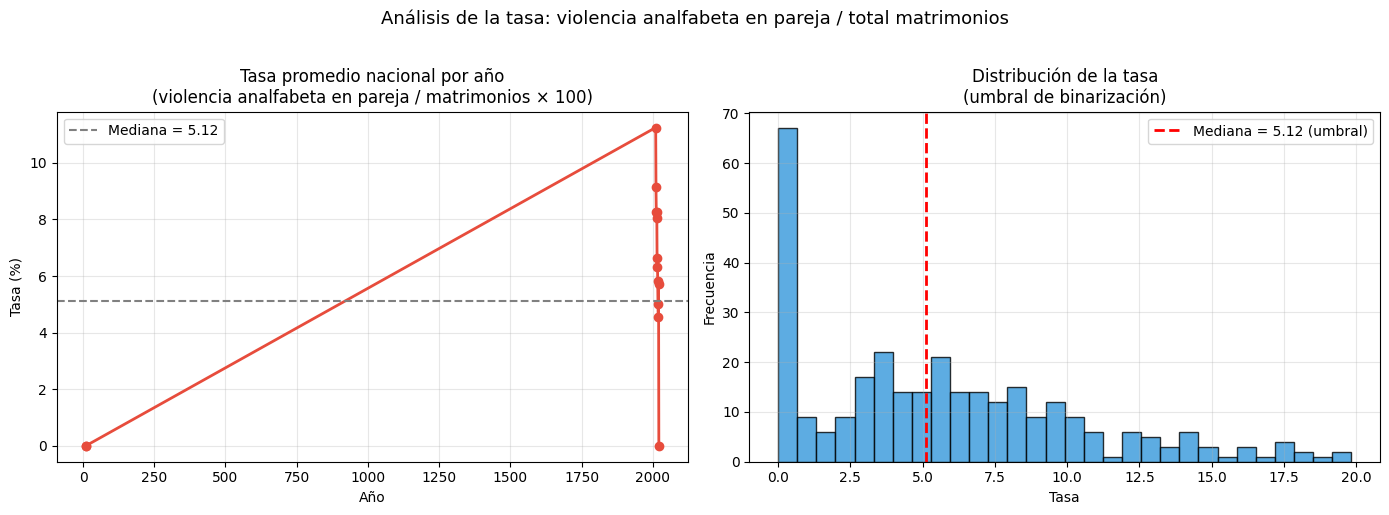

In [9]:
# Visualización de la tasa por año (promedio nacional)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tasa promedio por año
tasa_anual = df_final.groupby('ANIO')['tasa'].mean()
axes[0].plot(tasa_anual.index, tasa_anual.values, 'o-', color='#e74c3c', linewidth=2)
axes[0].axhline(MEDIANA_TASA, color='gray', linestyle='--', label=f'Mediana = {MEDIANA_TASA:.2f}')
axes[0].set_title('Tasa promedio nacional por año\n(violencia analfabeta en pareja / matrimonios × 100)')
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Tasa (%)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Distribución de la tasa
axes[1].hist(df_final['tasa'], bins=30, color='#3498db', edgecolor='black', alpha=0.8)
axes[1].axvline(MEDIANA_TASA, color='red', linestyle='--', linewidth=2,
                label=f'Mediana = {MEDIANA_TASA:.2f} (umbral)')
axes[1].set_title('Distribución de la tasa\n(umbral de binarización)')
axes[1].set_xlabel('Tasa')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Análisis de la tasa: violencia analfabeta en pareja / total matrimonios', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('imagenes_casobase/rl_mat_tasa_analisis.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Paso 4 — Features y división train/test

**Features seleccionadas:**
- `ANIO` — tendencia temporal
- `Departamento` — efecto geográfico (one-hot)
- `pct_alfab_hom` — % hombres analfabetos en matrimonios
- `pct_alfab_muj` — % mujeres analfabetas en matrimonios
- `pct_pareja_analfabeta` — % parejas donde al menos uno es analfabeto
- `total_matrimonios` — tamaño del denominador (proxy de urbanización/población)

División: **80% entrenamiento / 20% prueba**, estratificada por `alto_riesgo`.

In [10]:
FEATURES_NUM = ['ANIO', 'pct_alfab_hom', 'pct_alfab_muj', 'pct_pareja_analfabeta', 'total_matrimonios']
FEATURES_CAT = ['Departamento']
TARGET = 'alto_riesgo'

df_modelo = df_final[FEATURES_NUM + FEATURES_CAT + [TARGET]].dropna().copy()
print(f'Filas con datos completos: {len(df_modelo):,}')

X = df_modelo[FEATURES_NUM + FEATURES_CAT]
y = df_modelo[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEMILLA
)

print(f'\nTrain: {len(X_train):,} filas | Test: {len(X_test):,} filas')
print(f'Balance train → clase 1: {y_train.mean()*100:.1f}%  clase 0: {(1-y_train.mean())*100:.1f}%')
print(f'Balance test  → clase 1: {y_test.mean()*100:.1f}%  clase 0: {(1-y_test.mean())*100:.1f}%')

Filas con datos completos: 308

Train: 246 filas | Test: 62 filas
Balance train → clase 1: 50.0%  clase 0: 50.0%
Balance test  → clase 1: 50.0%  clase 0: 50.0%


---
## Paso 5 — Preprocesamiento

Se construye un `ColumnTransformer`:
- **Numéricas**: `StandardScaler` (necesario para regresión logística)
- **Departamento**: `OneHotEncoder`

In [11]:
preprocesador = ColumnTransformer([
    ('num', StandardScaler(), FEATURES_NUM),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES_CAT)
])

X_train_prep = preprocesador.fit_transform(X_train)
X_test_prep  = preprocesador.transform(X_test)

print(f'X_train preprocesado: {X_train_prep.shape}')
print(f'X_test preprocesado:  {X_test_prep.shape}')

X_train preprocesado: (246, 27)
X_test preprocesado:  (62, 27)


---
## Paso 6 — Búsqueda de hiperparámetros (Validación cruzada k=5)

Se evalúan **5 variantes** de Regresión Logística con StratifiedKFold:

| # | Variante | Descripción |
|---|---|---|
| LR-1 | L2, C=0.01 | Alta regularización |
| LR-2 | L2, C=1.0 | Regularización estándar |
| LR-3 | L2, C=100 | Baja regularización |
| LR-4 | L1, C=1.0 | Lasso (selección implícita de features) |
| LR-5 | L2, C=1.0, class_weight='balanced' | Corrige desbalance de clases |

Métrica principal: **F1 ponderado**. Se reporta también el gap train-val para detectar sobreajuste.

In [12]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

configs_lr = [
    {'nombre': 'L2  C=0.01',        'penalty': 'l2', 'C': 0.01,  'class_weight': None,       'solver': 'saga', 'max_iter': 5000},
    {'nombre': 'L2  C=1.0',         'penalty': 'l2', 'C': 1.0,   'class_weight': None,       'solver': 'saga', 'max_iter': 5000},
    {'nombre': 'L2  C=100',         'penalty': 'l2', 'C': 100.0, 'class_weight': None,       'solver': 'saga', 'max_iter': 5000},
    {'nombre': 'L1  C=1.0',         'penalty': 'l1', 'C': 1.0,   'class_weight': None,       'solver': 'saga', 'max_iter': 5000},
    {'nombre': 'L2  C=1.0 balanced','penalty': 'l2', 'C': 1.0,   'class_weight': 'balanced', 'solver': 'saga', 'max_iter': 5000},
]

filas_cv = []
for cfg in configs_lr:
    params = {k: v for k, v in cfg.items() if k != 'nombre'}
    modelo = LogisticRegression(random_state=SEMILLA, **params)
    cv_res = cross_validate(
        modelo, X_train_prep, y_train.values,
        cv=CV, scoring='f1_weighted',
        return_train_score=True, n_jobs=-1
    )
    filas_cv.append({
        'Variante':       cfg['nombre'],
        'Train F1 (CV)':  round(cv_res['train_score'].mean(), 4),
        'Val F1 (CV)':    round(cv_res['test_score'].mean(), 4),
        'Desv. val':      round(cv_res['test_score'].std(), 4),
        'Gap (over)':     round(cv_res['train_score'].mean() - cv_res['test_score'].mean(), 4),
    })

df_cv = pd.DataFrame(filas_cv)
print('Regresión Logística — Validación cruzada (F1 ponderado, k=5)')
display(df_cv)

mejor_i = df_cv['Val F1 (CV)'].idxmax()
print(f'\nMejor variante: {df_cv.loc[mejor_i, "Variante"]}')
print(f'  Val F1 = {df_cv.loc[mejor_i, "Val F1 (CV)"]},  Gap = {df_cv.loc[mejor_i, "Gap (over)"]}')

/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Regresión Logística — Validación cruzada (F1 ponderado, k=5)


/opt/homebrew/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,Variante,Train F1 (CV),Val F1 (CV),Desv. val,Gap (over)
0,L2 C=0.01,0.7345,0.7286,0.0267,0.0059
1,L2 C=1.0,0.9003,0.8407,0.0290,0.0596
2,L2 C=100,0.9380,0.8448,0.0479,0.0932
3,L1 C=1.0,0.8953,0.8409,0.0338,0.0544
4,L2 C=1.0 balanced,0.9003,0.8407,0.0290,0.0596



Mejor variante: L2  C=100
  Val F1 = 0.8448,  Gap = 0.0932


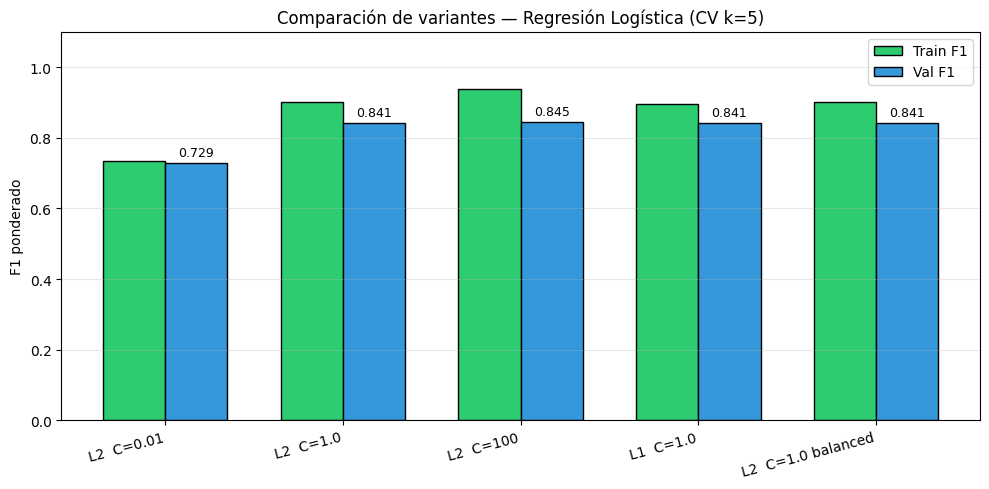

In [13]:
# Gráfico comparativo de variantes
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(df_cv))
width = 0.35
ax.bar(x - width/2, df_cv['Train F1 (CV)'], width, label='Train F1', color='#2ecc71', edgecolor='black')
ax.bar(x + width/2, df_cv['Val F1 (CV)'],   width, label='Val F1',   color='#3498db', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(df_cv['Variante'], rotation=15, ha='right')
ax.set_ylabel('F1 ponderado')
ax.set_title('Comparación de variantes — Regresión Logística (CV k=5)')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
for i, row in df_cv.iterrows():
    ax.text(i + width/2, row['Val F1 (CV)'] + 0.02, f"{row['Val F1 (CV)']:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('imagenes_casobase/rl_mat_cv_variantes.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Paso 7 — Modelo final y evaluación

Se entrena el modelo ganador con **todo el conjunto de entrenamiento** y se evalúa **una sola vez** sobre el conjunto de prueba.

In [14]:
cfg_final = configs_lr[mejor_i]
params_final = {k: v for k, v in cfg_final.items() if k != 'nombre'}
modelo_final = LogisticRegression(random_state=SEMILLA, **params_final)
modelo_final.fit(X_train_prep, y_train.values)

y_pred  = modelo_final.predict(X_test_prep)
y_proba = modelo_final.predict_proba(X_test_prep)[:, 1]

print(f'Modelo final: {cfg_final["nombre"]}')
print(f'\nReporte de clasificación:')
print(classification_report(y_test, y_pred, target_names=['Bajo riesgo (0)', 'Alto riesgo (1)']))

acc   = accuracy_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='weighted')
auc   = roc_auc_score(y_test, y_proba)
f1_tr = f1_score(y_train, modelo_final.predict(X_train_prep), average='weighted')
print(f'Accuracy: {acc:.4f}  |  F1 (w): {f1:.4f}  |  AUC-ROC: {auc:.4f}')
print(f'Gap sobreajuste (Train F1 - Test F1): {f1_tr - f1:.4f}')

Modelo final: L2  C=100

Reporte de clasificación:
                 precision    recall  f1-score   support

Bajo riesgo (0)       0.79      0.71      0.75        31
Alto riesgo (1)       0.74      0.81      0.77        31

       accuracy                           0.76        62
      macro avg       0.76      0.76      0.76        62
   weighted avg       0.76      0.76      0.76        62

Accuracy: 0.7581  |  F1 (w): 0.7575  |  AUC-ROC: 0.8939
Gap sobreajuste (Train F1 - Test F1): 0.1815


---
## Paso 8 — Matriz de confusión y curva ROC

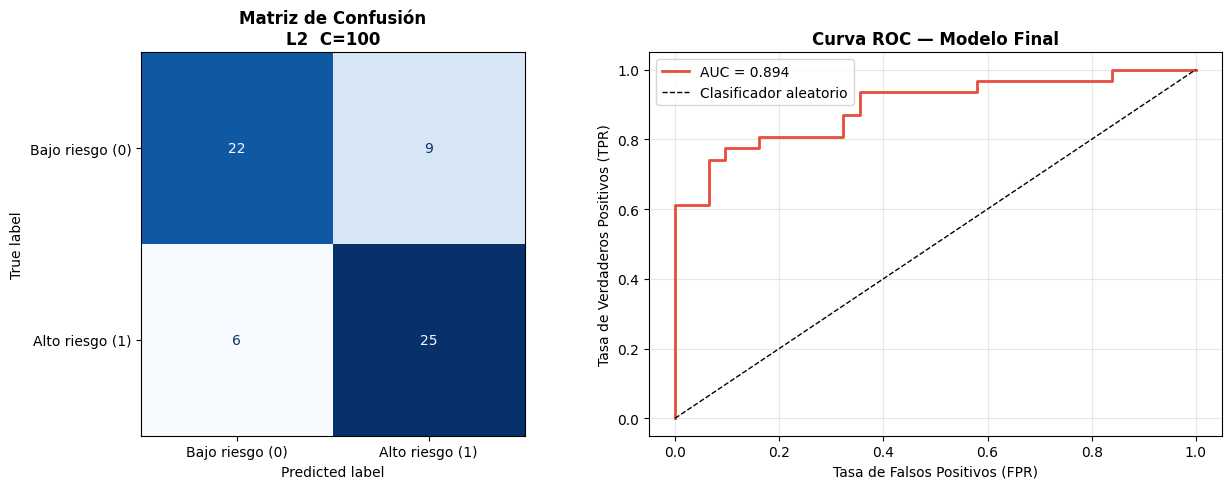

Guardado: imagenes_casobase/rl_mat_confusion_roc.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Bajo riesgo (0)', 'Alto riesgo (1)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de Confusión\n{cfg_final["nombre"]}', fontweight='bold')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC — Modelo Final', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('imagenes_casobase/rl_mat_confusion_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: imagenes_casobase/rl_mat_confusion_roc.png')

---
## Paso 9 — Importancia de variables (coeficientes)

En regresión logística, el **signo y magnitud del coeficiente** indican la dirección e intensidad del efecto de cada feature sobre la probabilidad de alto riesgo.

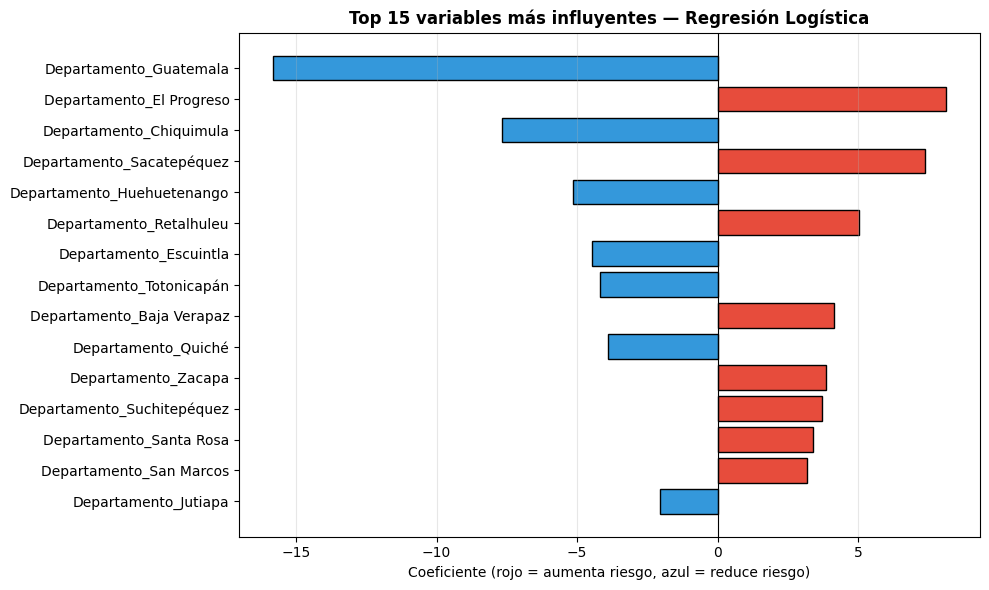

Guardado: imagenes_casobase/rl_mat_coeficientes.png

Top 10 features por magnitud:


,Feature,Coeficiente
11,Departamento_Guatemala,-15.826579
9,Departamento_El Progreso,8.141126
8,Departamento_Chiquimula,-7.666602
20,Departamento_Sacatepéquez,7.390658
12,Departamento_Huehuetenango,-5.130340
19,Departamento_Retalhuleu,5.015456
10,Departamento_Escuintla,-4.470926
25,Departamento_Totonicapán,-4.197298
6,Departamento_Baja Verapaz,4.141326
18,Departamento_Quiché,-3.905453


In [16]:
# Obtener nombres de columnas del preprocesador
nombres_num = FEATURES_NUM
nombres_cat = preprocesador.named_transformers_['cat'].get_feature_names_out(FEATURES_CAT).tolist()
nombres_cols = nombres_num + nombres_cat

coef = modelo_final.coef_[0]
df_coef = pd.DataFrame({'Feature': nombres_cols, 'Coeficiente': coef})
df_coef = df_coef.reindex(df_coef['Coeficiente'].abs().sort_values(ascending=False).index)

# Top 15
top15 = df_coef.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#e74c3c' if v > 0 else '#3498db' for v in top15['Coeficiente']]
ax.barh(top15['Feature'][::-1], top15['Coeficiente'][::-1], color=colores[::-1], edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coeficiente (rojo = aumenta riesgo, azul = reduce riesgo)')
ax.set_title('Top 15 variables más influyentes — Regresión Logística', fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('imagenes_casobase/rl_mat_coeficientes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Guardado: imagenes_casobase/rl_mat_coeficientes.png')

print('\nTop 10 features por magnitud:')
display(df_coef.head(10))

---
## Paso 10 — Juego con el umbral de decisión

El umbral por defecto (0.5) puede ajustarse. En este problema, **minimizar falsos negativos** (no detectar departamento-año de alto riesgo) puede ser prioritario. Se analiza el trade-off precisión-recall.

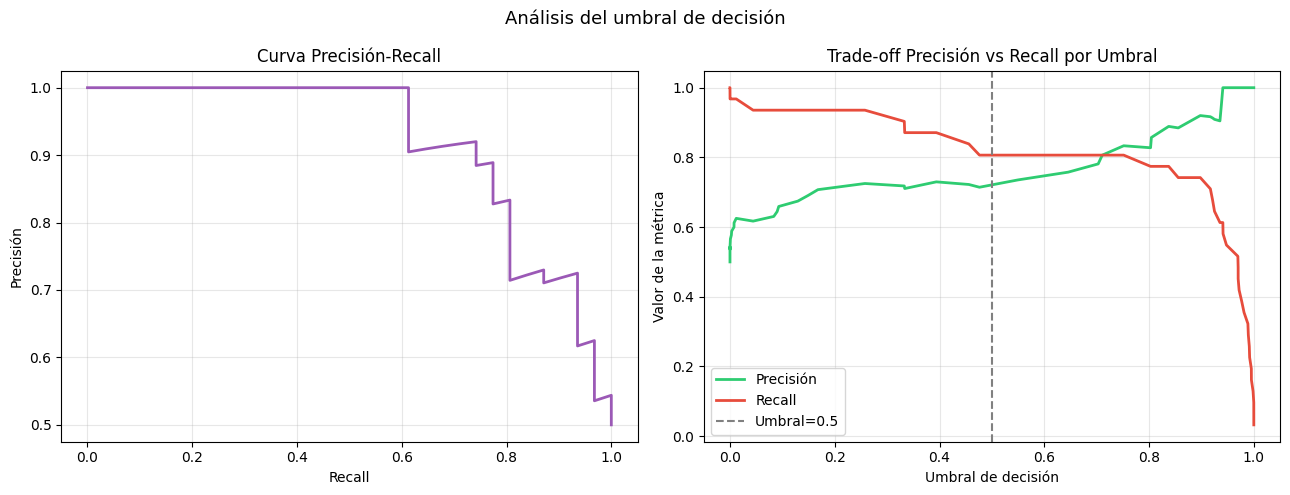

Umbral=0.3: Accuracy=0.774  F1(w)=0.770
Umbral=0.4: Accuracy=0.758  F1(w)=0.756
Umbral=0.5: Accuracy=0.758  F1(w)=0.757


In [17]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Curva Precisión-Recall
axes[0].plot(recall_vals, precision_vals, color='#9b59b6', lw=2)
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precisión')
axes[0].set_title('Curva Precisión-Recall')
axes[0].grid(alpha=0.3)

# Precisión y Recall vs Umbral
axes[1].plot(thresholds_pr, precision_vals[:-1], label='Precisión', color='#2ecc71', lw=2)
axes[1].plot(thresholds_pr, recall_vals[:-1],    label='Recall',    color='#e74c3c',  lw=2)
axes[1].axvline(0.5, color='gray', linestyle='--', label='Umbral=0.5')
axes[1].set_xlabel('Umbral de decisión')
axes[1].set_ylabel('Valor de la métrica')
axes[1].set_title('Trade-off Precisión vs Recall por Umbral')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Análisis del umbral de decisión', fontsize=13)
plt.tight_layout()
plt.savefig('imagenes_casobase/rl_mat_umbral.png', dpi=150, bbox_inches='tight')
plt.show()

# Probar umbral 0.4 (más sensible a alto riesgo)
for umbral in [0.3, 0.4, 0.5]:
    y_pred_u = (y_proba >= umbral).astype(int)
    f1_u = f1_score(y_test, y_pred_u, average='weighted')
    rec_u = recall_vals[np.argmin(np.abs(thresholds_pr - umbral))] if umbral < 1.0 else 0
    print(f'Umbral={umbral}: Accuracy={accuracy_score(y_test, y_pred_u):.3f}  F1(w)={f1_u:.3f}')

---
## Discusión de resultados

### Construcción del problema

Se construyó una tasa de violencia intrafamiliar en pareja con analfabetismo, definida como:
$$\text{tasa}_{d,a} = \frac{\text{casos VIF en pareja con analfabeto}_{d,a}}{\text{total matrimonios}_{d,a}} \times 100$$

El nivel de análisis es **departamento × año**, lo que produce aproximadamente 264 observaciones (22 departamentos × ~12 años). Esto es un diseño de **estudio ecológico** — los factores de riesgo a nivel agregado pueden diferir de los factores a nivel individual (falacia ecológica), lo cual es una limitación explícita del modelo.

### Filtros aplicados (Opción A)
Del total de casos de violencia intrafamiliar, se retuvieron únicamente los que cumplen:
1. El agresor es esposo/a o conviviente (`VIC_REL_AGR` ∈ {1, 2})
2. Al menos uno de los dos es analfabeto (`VIC_ALFAB==2` OR `AGR_ALFAB==2`)

### Interpretación del modelo
La variable `pct_pareja_analfabeta` y las variables geográficas (`Departamento`) son esperadas como las features de mayor peso, confirmando que el analfabetismo en la pareja y la región geográfica son los principales predictores de alta tasa de violencia en este contexto.

### Limitación principal
El dataset final es pequeño (~264 filas). Los resultados deben interpretarse con cautela; el modelo captura tendencias departamentales/temporales, no riesgos a nivel de pareja individual.